# Le modèle calibré, de bout en bout

Les cinq carnets précédents ont procédé par questions : que vaut la méthode de référence, que
laisse-t-elle de côté, que voit un capteur quand une fuite s'ouvre, que disent les débitmètres
seuls, et le regroupement des conduites était-il le bon. Ce carnet-ci ne pose plus de question :
il **construit le modèle**, dans l'ordre, avec les réponses.

Le fil est un principe et une conséquence.

> **On mesure d'abord. On n'ajuste qu'à la fin, et une seule fois.**

Sur ce réseau, presque tout ce qu'on serait tenté d'ajuster est en réalité **lu quelque part** :
l'état de la pompe est au débitmètre, le niveau du réservoir à son capteur, la demande de la zone C
aux 82 compteurs, le niveau de demande de A+B au bilan des débitmètres. Chacune de ces lectures
coûte deux lignes et rapporte davantage que l'optimisation qui prétendrait la remplacer. Il ne
reste ensuite qu'un seul vrai paramètre libre — la rugosité — et le carnet montre comment le régler
sans lui faire dire n'importe quoi.

| étape | ce qu'on fait | d'où ça vient | ajustement ? |
|---|---|---|---|
| 1 | état de la pompe et niveau du réservoir | débitmètre `PUMP_1`, capteur de niveau | non, lecture |
| 2 | demande des 82 jonctions équipées | compteurs AMR | non, lecture |
| 3 | demande des 690 jonctions de A+B | formes horaires des compteurs × nominal du fichier | non, déduction |
| 4 | rugosité de 13 groupes de conduites | moindres carrés, fenêtre sans fuite | **oui, une fois** |

La dernière section tranche une question que les carnets précédents ont posée sans y répondre :
faut-il recaler la demande de A+B sur le bilan de masse ? La réponse dépend de ce qu'on veut faire
du modèle, et elle se mesure.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, rugosite as U, ameliorations as A, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
DEBUT, N_PAS = 181 * R.PAS_JOUR, 7 * R.PAS_JOUR       # on ÉVALUE en juillet
DEBUT_ENTR, N_ENTR = 0, 2 * R.PAS_JOUR                # on AJUSTE sur la semaine 1

R.verifier_donnees(ANNEE)
wn = R.charger_modele(duree_h=24)
noeuds = wn.junction_name_list
zones = R.zones(wn)
horo = R.horodatage(ANNEE)
niveau = R.charger_niveau(ANNEE).to_numpy()
statut = A.statut_pompe(ANNEE)
pression = R.charger_pressions(ANNEE).to_numpy()
mesure = pression[DEBUT:DEBUT + N_PAS]

print("fenêtre d'ajustement :", R.charge_de_fuite(ANNEE, DEBUT_ENTR, N_ENTR))
print("fenêtre d'évaluation :", R.charge_de_fuite(ANNEE, DEBUT, N_PAS))

fenêtre d'ajustement : {'debit_m3h': 0.0, 'fuites_vives': 0.0, 'part_conso_ab': 0.0}


fenêtre d'évaluation : {'debit_m3h': 12.281656746031747, 'fuites_vives': 3.0, 'part_conso_ab': 0.07018089569160998}


La fenêtre d'ajustement porte **0 m³/h** de fuite, celle d'évaluation en porte une douzaine. C'est
volontaire : on règle sur un réseau sain et on évalue sur un réseau qui fuit, jamais l'inverse.

## 1. Le point de départ, et ce qu'on cherche à voir

Le modèle tel qu'il est livré, sans rien toucher.

In [2]:
D_livre, _ = P.demandes_nominales(wn, horo[DEBUT:DEBUT + N_PAS + 1])
S_livre = R.pressions_simulees(D_livre, noeuds, N_PAS, tranche_jours=7,
                               niveau0=float(niveau[DEBUT]), verbeux=False)

print(pd.Series(G.resume(S_livre, mesure)).round(3).to_string())

biais_m            0.341
dispersion_m       0.329
rmse_m             0.474
max_m              2.285
n_pas           2016.000


### Pourquoi la dispersion et pas la RMSE

`RMSE² = biais² + dispersion²`. Le **biais** est un décalage constant : il disparaît dans toute
différence, donc dans tout détecteur qui compare un instant à un autre. La **dispersion** est ce
qui reste, et c'est elle qui masque un signal.

L'ordre de grandeur à garder en tête vient du carnet 3 : une fuite de 10 m³/h fait baisser le
capteur le plus proche de **8,9 à 99,5 cm** selon l'endroit où elle s'ouvre. Le modèle livré, lui,
disperse de 33 cm sur cette semaine — 39 cm sur l'année. Toute la calibration consiste à faire
passer la seconde sous la première.

## 2. Étape 1 — les conditions aux limites : deux capteurs, aucun ajustement

Le fichier pilote la pompe par deux consignes de niveau que la vraie pompe ne respecte pas, et
laisse le réservoir dériver librement. Les deux sont mesurés. On les lit.

In [3]:
bc = dict(pompe=statut[DEBUT:DEBUT + N_PAS + 1],
          niveau_mesure=niveau[DEBUT:DEBUT + N_PAS + 1])

def simuler_juillet(D, **kw):
    # les pressions aux 33 capteurs sur la semaine d'évaluation, réancrage toutes les 6 heures
    return R.pressions_simulees(D, noeuds, N_PAS, tranche_jours=0.25,
                                niveau0=float(niveau[DEBUT]), verbeux=False, **kw)

S_bc = simuler_juillet(D_livre, **bc)
print(G.tableau({"modèle livré": S_livre, "+ pompe et niveau lus": S_bc}, mesure).round(3).to_string())

                       biais_m  dispersion_m  rmse_m  max_m   n_pas  gain_dispersion  gain_rmse
modèle livré             0.341         0.329   0.474  2.285  2016.0            0.000      0.000
+ pompe et niveau lus    0.276         0.213   0.349  1.763  2016.0           -0.352     -0.264


### Lecture

Deux capteurs déjà présents, aucun modèle, aucun optimiseur : **un tiers de la dispersion s'en
va**, et le maximum d'erreur passe de 2,29 m à 1,76 m. Rapporté au coût — deux arguments passés à
une fonction — c'est le meilleur rendement du dépôt, et le moins savant.

Le pas de réancrage compte : le carnet 2 mesure qu'en passant de 24 h à 6 h on retire encore un
quart de la RMSE annuelle. On garde 6 h ici, et jusqu'au bout du carnet.

## 3. Étape 2 — la zone C : la demande y est mesurée, alors on la mesure

Les 82 compteurs couvrent 82 des 92 jonctions de la zone C. Le modèle de demande du carnet 1
applique pourtant l'équation (2) à **toutes** les jonctions, y compris à celles-là : il remplace
une mesure par une estimation. `injecter_compteurs` remet la mesure à sa place.

In [4]:
D_annee, _ = P.demandes_calibrees(wn, ANNEE)     # l'équation (2) sur l'année, 330 Mo
fen = slice(DEBUT, DEBUT + N_PAS + 1)

D_1 = D_annee[fen]                                              # équation (2) partout
D_2 = A.injecter_compteurs(D_1, noeuds, ANNEE, debut=DEBUT)      # zone C mesurée

est_c = np.array([zones[n] == "C" for n in noeuds])
print(f"zone C, demande modélisée : {D_1[:, est_c].sum(axis=1).mean():.2f} m³/h")
print(f"zone C, demande mesurée   : {D_2[:, est_c].sum(axis=1).mean():.2f} m³/h")
print(f"erreur du modèle sur le total de la zone : "
      f"{D_1[:, est_c].sum(axis=1).mean() / D_2[:, est_c].sum(axis=1).mean() - 1:+.1%}")

zone C, demande modélisée : 22.02 m³/h
zone C, demande mesurée   : 21.66 m³/h
erreur du modèle sur le total de la zone : +1.7%


In [5]:
S_1 = simuler_juillet(D_1, **bc)
S_2 = simuler_juillet(D_2, **bc)

print(G.tableau({"conditions aux limites seules": S_bc,
                 "+ modèle de demande": S_1,
                 "+ compteurs de la zone C": S_2}, mesure).round(3).to_string())

                               biais_m  dispersion_m  rmse_m  max_m   n_pas  gain_dispersion  gain_rmse
conditions aux limites seules    0.276         0.213   0.349  1.763  2016.0            0.000      0.000
+ modèle de demande              0.160         0.139   0.212  1.505  2016.0           -0.347     -0.393
+ compteurs de la zone C         0.160         0.135   0.209  0.828  2016.0           -0.367     -0.400


### Lecture

La zone C ne porte que 12 % de la demande du réseau et se trouve derrière un réservoir qui découple
ses pressions du reste. L'injection des compteurs ne peut donc pas déplacer beaucoup les 33
capteurs, et ne le fait pas : 0,4 % de dispersion en moins.

Elle fait autre chose, et le tableau le montre : le **maximum d'erreur tombe de 1,51 m à 0,83 m**.
Ce que le modèle de demande ratait, ce n'était pas le niveau moyen de la zone C — il ne se trompe
que de 1,7 % dessus — c'étaient ses pointes. Un compteur les donne, une forme moyenne ne les invente
pas.

Et surtout, cette étape se juge sur ce qu'elle rend possible après : la zone C devient la seule
partie du réseau dont on connaît la consommation nœud par nœud, donc la seule où l'on saura **où**
est la fuite. Le carnet 4 en tire un débitmètre de fuite à 0,08 m³/h de biais.

## 4. Étape 3 — la zone A+B : le modèle de demande, et surtout ce qu'on ne lui fait pas

690 jonctions, aucun compteur. On leur applique les formes horaires estimées sur les 82 compteurs,
pondérées par la demande nominale du fichier — c'est l'équation (2) du carnet 1. La question est
de savoir si ce modèle est bon, et le fichier de fuites permet d'y répondre pour de bon.

In [6]:
est_ab = ~est_c
fuites = R.charger_fuites(ANNEE)
en_c = [p for p in fuites.columns
        if zones.get(wn.get_link(p).start_node_name) == "C"
        and zones.get(wn.get_link(p).end_node_name) == "C"]
fuite_ab = fuites[[p for p in fuites.columns if p not in en_c]].sum(axis=1)

modele_ab = pd.Series(D_annee[:len(horo), est_ab].sum(axis=1, dtype=float), index=horo)
bilan_ab = A.demande_ab_mesuree(ANNEE)
reel_ab = bilan_ab - fuite_ab

print("moyennes sur l'année :")
print(f"  modèle de demande        : {modele_ab.mean():.1f} m³/h")
print(f"  bilan des débitmètres    : {bilan_ab.mean():.1f} m³/h")
print(f"  bilan moins fuites vraies: {reel_ab.mean():.1f} m³/h")
print(f"\nécart du modèle à la consommation réelle : {modele_ab.mean() / reel_ab.mean() - 1:+.1%}")

moyennes sur l'année :
  modèle de demande        : 157.0 m³/h
  bilan des débitmètres    : 174.9 m³/h
  bilan moins fuites vraies: 156.7 m³/h

écart du modèle à la consommation réelle : +0.2%


### Lecture — et la décision qui en découle

**Le modèle de demande est juste.** Il ne s'écarte de la consommation réelle de A+B que de quelques
dixièmes de pour cent, alors qu'il est construit à partir de compteurs situés **tous** dans l'autre
zone. Ce qui le séparait du bilan des débitmètres, c'étaient les fuites, en totalité.

D'où la décision de ce carnet : **on ne recale pas la demande de A+B sur le bilan de masse.**

Le levier 4 du carnet 2 fait ce recalage et améliore nettement les pressions. Ce n'est pas
contradictoire : l'eau qui fuit circule réellement dans les conduites, donc la répartir comme de la
demande rapproche le modèle de la réalité hydraulique. Mais elle la rapproche **en inscrivant la
fuite dans la demande**, là où un détecteur a précisément besoin de la voir rester dans le résidu.

La section 6 mesure ce que chacun des deux choix coûte et rapporte, au lieu d'en débattre.

## 5. Étape 4 — les rugosités : le seul ajustement du carnet

Avant d'optimiser quoi que ce soit, deux diagnostics d'une ligne chacun. Ils coûtent moins qu'une
itération et ils annoncent le résultat.

In [7]:
# 1) Combien de charge une conduite perd-elle réellement ?
pertes = U.pertes_de_charge(D_2[:R.PAS_JOUR + 1], noeuds, R.PAS_JOUR, tranche_jours=1,
                            niveau0=float(niveau[DEBUT]), verbeux=False,
                            pompe=statut[DEBUT:DEBUT + R.PAS_JOUR + 1],
                            niveau_mesure=niveau[DEBUT:DEBUT + R.PAS_JOUR + 1])
print(f"perte de charge médiane d'une conduite : {pertes.mediane_m.median() * 1000:.2f} mm")

# 2) Un groupe de conduites contient-il une seule valeur vraie, ou plusieurs ?
rug = pd.Series({p: wn.get_link(p).roughness for p in wn.pipe_name_list})
for critere, nom in [("diametre", "par diamètre (6 groupes)"), ("physique", "zone × coefficient × diamètre")]:
    g = pd.Series(R.groupes_de_rugosite(wn, n_groupes=6, critere=critere))
    melanges = rug.groupby(g).nunique()
    print(f"{nom:32s} : {len(melanges)} groupes, "
          f"{(melanges > 1).sum()} hétérogènes, couvrant {g.isin(melanges[melanges > 1].index).sum()} conduites")

perte de charge médiane d'une conduite : 3.81 mm
par diamètre (6 groupes)         : 6 groupes, 3 hétérogènes, couvrant 813 conduites
zone × coefficient × diamètre    : 13 groupes, 0 hétérogènes, couvrant 0 conduites


Le premier chiffre dit que la friction n'a presque aucune prise : la conduite médiane perd
quatre millimètres de charge, quand l'erreur du modèle se compte en dizaines de centimètres.

Le second dit pourquoi le regroupement par diamètre seul ne pouvait pas converger : trois de ses
six groupes réunissent des conduites dont le coefficient vrai diffère, et un paramètre unique ne
peut pas valoir 120 et 140 à la fois. Le regroupement par **zone × coefficient × diamètre**, lui,
est homogène par construction.

On ajuste donc sur ce regroupement-là, sur la fenêtre sans fuite, et avec un encadrement tiré des
valeurs que chaque groupe porte réellement plutôt que de l'intervalle (60, 160) de la publication —
qui, le fichier ne contenant que deux coefficients, autorise −56 % à +17 % et ne contraint rien.

In [8]:
groupes = R.groupes_de_rugosite(wn, critere="physique")
depart = U.coefficients_initiaux(wn, groupes)
bornes = U.bornes_par_groupe(wn, groupes, marge=0.10)

D_entr = A.injecter_compteurs(D_annee[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1], noeuds, ANNEE,
                              debut=DEBUT_ENTR)
bc_entr = dict(pompe=statut[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1],
               niveau_mesure=niveau[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1])

def simulateur(coefficients):
    return R.pressions_simulees(D_entr, noeuds, N_ENTR, tranche_jours=0.25,
                                niveau0=float(niveau[DEBUT_ENTR]), verbeux=False,
                                coefficients=U.coefficients_par_conduite(groupes, coefficients),
                                **bc_entr)

ajustement = U.ajuster(simulateur, pression[DEBUT_ENTR:DEBUT_ENTR + N_ENTR], depart,
                       bornes=bornes, max_nfev=10, verbeux=False)   # quelques minutes
print(f"{ajustement['n_evaluations']} simulations en {ajustement['secondes']:.0f} s ; "
      f"RMSE d'ajustement {ajustement['rmse_depart']:.4f} → {ajustement['rmse']:.4f} m")
print(f"groupes arrêtés sur une borne : {ajustement['aux_bornes'] or 'aucun'}")

128 simulations en 263 s ; RMSE d'ajustement 0.0971 → 0.0500 m
groupes arrêtés sur une borne : aucun


In [9]:
t = pd.DataFrame({"départ": ajustement["depart"], "ajusté": ajustement["coefficients"]})
t["écart"] = t["ajusté"] - t["départ"]
t["conduites"] = pd.Series(groupes).value_counts()
print(t.round(1).sort_values("conduites", ascending=False).to_string())

                     départ  ajusté  écart  conduites
AB|C140|D100          140.0   129.5  -10.5        497
AB|C120|D100          120.0   108.0  -12.0        104
C|C140|D100           140.0   126.7  -13.3        104
AB|C140|D150          140.0   141.3    1.3         90
AB|C140|D200          140.0   127.4  -12.6         57
AB|C140|D160          140.0   151.3   11.3         16
AB|C120|D150          120.0   108.0  -12.0         13
AB|C140|D225          140.0   147.7    7.7         12
C|C140|D200           140.0   154.0   14.0          4
frontiere|C140|D200   140.0   154.0   14.0          3
AB|C120|D63           120.0   131.5   11.5          2
AB|C140|D63           140.0   126.7  -13.3          2
AB|C140|D75           140.0   126.0  -14.0          1


In [10]:
coefs = U.coefficients_par_conduite(groupes, ajustement["coefficients"])
S_3 = simuler_juillet(D_2, **bc, coefficients=coefs)

print(G.tableau({"sans ajustement": S_2, "+ 13 rugosités ajustées": S_3}, mesure).round(3).to_string())

                         biais_m  dispersion_m  rmse_m  max_m   n_pas  gain_dispersion  gain_rmse
sans ajustement            0.160         0.135   0.209  0.828  2016.0            0.000      0.000
+ 13 rugosités ajustées    0.054         0.120   0.131  0.698  2016.0           -0.113     -0.372


### Lecture

L'ajustement travaille surtout sur le **biais** : il le divise par trois (0,160 → 0,054 m) et ne
retire que 11 % de dispersion. C'est le comportement attendu d'un paramètre sans prise — la
conduite médiane perd quatre millimètres de charge — qui ne peut guère que déplacer l'ensemble des
pressions.

Deux choses méritent d'être relevées dans le tableau des coefficients. Aucun groupe ne s'arrête sur
une borne, ce qui n'était pas le cas avec l'encadrement (60, 160) de la publication : l'encadrement
tiré des valeurs portées suffit à contenir l'ajustement sans le contraindre. Et les écarts vont
presque tous dans le même sens, −10 à −14 unités : l'optimiseur ne redistribue pas la friction entre
groupes, il **baisse tout**. Ce qu'il corrige ressemble donc à une erreur globale, pas à une carte
de rugosités.

Raison de plus pour ne pas croire les coefficients un par un. Le carnet 5 montre que quatre groupes
couvrant 748 conduites sur 905 sont stables d'une fenêtre à l'autre, et que l'instabilité se
concentre sur sept conduites nommées : `p227` et `p235`, les entrées du réseau, `p239`, la sortie du
réservoir, et `p240`, `p316`, `p317`, `p318`, la conduite de transport de la zone C. Ces
coefficients-là ne mesurent pas de la friction : ils compensent une condition aux limites.

## 6. Simuler ou détecter : le même réseau, deux modèles

Reste la question laissée en suspens au §4. On la tranche par une mesure plutôt que par un
argument.

L'idée du test : si un modèle **absorbe** les fuites, son biais doit être à peu près le même sur
une fenêtre saine et sur une fenêtre qui fuit — puisque la fuite est passée dans la demande. Si au
contraire il les **laisse dans le résidu**, son biais doit croître avec la charge de fuite. On
prend donc huit fenêtres de trois jours réparties sur l'année, on mesure leur charge de fuite dans
le fichier publié, et on regarde.

In [11]:
D_detect = D_2                                                        # tel quel
D_simule = A.recaler_zone_ab(D_2, noeuds, wn, ANNEE, debut=DEBUT)     # recalé sur le bilan brut

print(G.tableau({"pour détecter (non recalé)": simuler_juillet(D_detect, **bc, coefficients=coefs),
                 "pour simuler (recalé)": simuler_juillet(D_simule, **bc, coefficients=coefs)},
                mesure).round(3).to_string())

                            biais_m  dispersion_m  rmse_m  max_m   n_pas  gain_dispersion  gain_rmse
pour détecter (non recalé)    0.054         0.120   0.131  0.698  2016.0            0.000      0.000
pour simuler (recalé)         0.018         0.125   0.126  0.692  2016.0            0.044     -0.038


In [12]:
FENETRES = [10, 60, 110, 160, 210, 260, 310, 350]     # jours de départ, 3 jours chacune
n = 3 * R.PAS_JOUR
lignes = []
for j in FENETRES:
    d = j * R.PAS_JOUR
    D = A.injecter_compteurs(D_annee[d:d + n + 1], noeuds, ANNEE, debut=d)
    kw = dict(pompe=statut[d:d + n + 1], niveau_mesure=niveau[d:d + n + 1], coefficients=coefs)
    faire = lambda E: R.pressions_simulees(E, noeuds, n, tranche_jours=0.25,
                                           niveau0=float(niveau[d]), verbeux=False, **kw)
    lignes.append({
        "jour": j,
        "fuite_m3h": R.charge_de_fuite(ANNEE, d, n)["debit_m3h"],
        "biais_detect": G.resume(faire(D), pression[d:d + n])["biais_m"],
        "biais_simule": G.resume(faire(A.recaler_zone_ab(D, noeuds, wn, ANNEE, debut=d)),
                                 pression[d:d + n])["biais_m"]})
essai = pd.DataFrame(lignes)
print(essai.round(3).to_string(index=False))

 jour  fuite_m3h  biais_detect  biais_simule
   10      0.391        -0.008        -0.005
   60     18.598         0.076        -0.001
  110      9.612         0.031         0.016
  160     26.225         0.123        -0.022
  210     26.064         0.091         0.051
  260     19.225         0.123         0.018
  310     36.736         0.266         0.031
  350     24.088         0.129         0.012


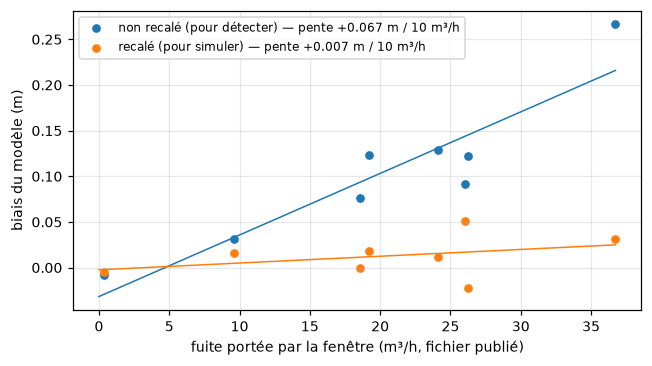

In [13]:
fig, ax = plt.subplots(figsize=(6.0, 3.4))
for col, lib in [("biais_detect", "non recalé (pour détecter)"), ("biais_simule", "recalé (pour simuler)")]:
    pente, ordonnee = np.polyfit(essai.fuite_m3h, essai[col], 1)
    ax.scatter(essai.fuite_m3h, essai[col], s=22, label=f"{lib} — pente {pente * 10:+.3f} m / 10 m³/h")
    x = np.linspace(0, essai.fuite_m3h.max(), 10)
    ax.plot(x, pente * x + ordonnee, lw=1)
ax.set_xlabel("fuite portée par la fenêtre (m³/h, fichier publié)")
ax.set_ylabel("biais du modèle (m)")
ax.legend(fontsize=8); fig.tight_layout()

### Lecture

Le test répond sans ambiguïté. Le biais du modèle **non recalé** suit la charge de fuite : presque
nul sur la fenêtre saine de janvier (0,4 m³/h de fuite → −0,008 m), il monte à 0,27 m sur la
fenêtre d'octobre qui en porte 37. Celui du modèle **recalé** reste plat entre −0,02 et +0,05 m,
quelle que soit la fuite : le recalage a déjà versé le volume supplémentaire dans la demande des
690 nœuds, il n'en reste rien dans le résidu.

C'est le même réseau, les mêmes capteurs, les mêmes rugosités. Ce qui change est ce qu'on accepte
de laisser dans le résidu. **Un modèle de simulation et un modèle de détection ne sont pas le même
objet**, et vouloir le meilleur des deux sur la même sortie n'a pas de sens.

## 7. Sur l'année entière, et les deux modèles qu'on ne peut pas construire

Une semaine de juillet ne prouve rien : on refait l'empilement sur les 105 120 pas de 2018.

L'occasion d'ajouter deux modèles qui **utilisent le fichier de fuites** et ne sont donc pas
reproductibles sur une année ordinaire. Ils ne servent pas à calibrer : ils servent à savoir ce que
valent les deux autres.

| variante | demande de A+B | fuites dans le modèle | utilisable sans le fichier de fuites ? |
|---|---|---|---|
| détection | formes des compteurs × nominal | absentes | **oui** |
| détection, cible sans fuites | bilan − fuites publiées | absentes | non |
| simulation | bilan brut | diluées sur 690 nœuds | **oui** |
| fidèle | bilan − fuites publiées | **posées à leur conduite** | non |

Deux questions, une par modèle ajouté.

**La deuxième ligne** demande si le modèle de demande des compteurs perd quelque chose face à la
meilleure demande sans fuite qu'on puisse construire — celle qui est recalée sur un instrument à
chaque pas plutôt que déduite. Si les deux se valent, le fichier de fuites n'apporte rien à la
calibration, et la ligne « détection » n'est pas un pis-aller : c'est l'optimum.

**La quatrième** remet tout ce qu'on sait de 2018 : la vraie demande et les vraies fuites, chacune
au bon endroit. Son erreur est le **plancher** — ce que le modèle ne saura pas expliquer même en
connaissant la réponse. Elle tranche la question que le §6 laisse ouverte : quand le modèle de
détection s'écarte de la mesure, est-ce la fuite qu'on voit, ou du bruit de modèle ?

In [14]:
# Une variante à la fois : chaque tableau de demande annuel pèse 330 Mo.
sans_fuite = bilan_ab - fuite_ab              # la consommation réelle de A+B, pas par pas

def demande(nom):
    if nom == "modèle livré":
        return P.demandes_nominales(wn, horo)[0]
    base = A.injecter_compteurs(D_annee, noeuds, ANNEE)
    if nom == "détection (compteurs seuls)":
        return base
    propre = A.recaler_zone_ab(base, noeuds, wn, ANNEE, cible=sans_fuite)
    if nom == "détection, cible sans fuites":
        return propre
    if nom == "simulation (bilan brut)":
        return A.recaler_zone_ab(base, noeuds, wn, ANNEE)
    return A.poser_fuites_publiees(propre, noeuds, wn, ANNEE)          # fidèle

sorties = {}
for nom in ["modèle livré", "détection (compteurs seuls)", "détection, cible sans fuites",
            "simulation (bilan brut)", "fidèle (fuites à leur conduite)"]:
    D = demande(nom)
    kw = {} if nom == "modèle livré" else dict(pompe=statut, niveau_mesure=niveau, coefficients=coefs)
    sorties[nom] = R.pressions_simulees(D[:R.PAS_AN + 1], noeuds, R.PAS_AN, tranche_jours=0.25,
                                        niveau0=float(niveau[0]), verbeux=False, **kw)
    del D
    print(f"{nom} : fait", flush=True)

annuel = G.tableau(sorties, pression)
print(annuel[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion", "gain_rmse"]].round(4).to_string())

modèle livré : fait


détection (compteurs seuls) : fait


détection, cible sans fuites : fait


simulation (bilan brut) : fait


fidèle (fuites à leur conduite) : fait


                                 biais_m  dispersion_m  rmse_m  gain_dispersion  gain_rmse
modèle livré                      0.3095        0.3890  0.4971           0.0000     0.0000
détection (compteurs seuls)       0.1538        0.2071  0.2579          -0.4677    -0.4811
détection, cible sans fuites      0.1563        0.2070  0.2594          -0.4678    -0.4781
simulation (bilan brut)           0.0140        0.1604  0.1610          -0.5876    -0.6761
fidèle (fuites à leur conduite)  -0.0126        0.0856  0.0865          -0.7799    -0.8259


### Lecture

Les deux modèles ajoutés répondent chacun à leur question, et les deux réponses sont nettes.

**Le fichier de fuites n'apporte rien à la calibration.** Les lignes « détection » et « détection,
cible sans fuites » sont identiques à la quatrième décimale : 0,2071 contre 0,2070 m de dispersion.
Recaler la demande de A+B sur un instrument, à chaque pas, sur une cible débarrassée des fuites, ne
fait pas mieux que de la déduire des 82 compteurs de la zone C. Le modèle de demande du carnet 1
n'est donc pas un pis-aller en attendant la mesure : sur cette grandeur, **il est la mesure**.

**Le résidu du modèle de détection est bien la fuite.** Le modèle fidèle — même demande sans fuite,
mais les fuites publiées posées chacune à sa conduite — descend à **0,0856 m** de dispersion, soit
2,4 fois moins que le modèle de détection et près de deux fois moins que le modèle de simulation.
C'est le plancher : ce que le modèle ne sait pas expliquer même en connaissant la réponse.

Le reste se lit par soustraction quadratique. Des 0,207 m de dispersion du modèle de détection,
0,086 sont du bruit de modèle et **0,19 m sont attribuables aux fuites**. C'est ce que le §6
montrait sur huit fenêtres ; on a maintenant le chiffre annuel.

Et la comparaison des deux façons de traiter la même eau est sans appel : diluée sur 690 nœuds
(simulation) elle laisse 0,136 m de dispersion en trop ; posée à sa conduite (fidèle) elle n'en
laisse aucune. Ce n'est pas la quantité d'eau qui manquait au modèle livré, c'est son **adresse**.

## Ce qu'il faut retenir

1. **Presque rien ne s'ajuste, presque tout se lit.** Sur les quatre étapes, une seule est une
   optimisation, et c'est celle qui rapporte le moins. Avant d'ouvrir un optimiseur, faire
   l'inventaire de ce que les capteurs donnent déjà.
2. **Le plus gros gain est le moins savant** : lire l'état de la pompe et réancrer le niveau du
   réservoir retire 0,116 m de dispersion sur la semaine de juillet, contre 0,093 m pour les trois
   étapes suivantes réunies.
3. **Un diagnostic d'une ligne vaut mieux qu'une optimisation de dix minutes.** La perte de charge
   médiane — 3,8 mm — annonçait que la rugosité ne paierait pas ; le décompte des valeurs vraies
   par groupe annonçait que six groupes par diamètre ne pouvaient pas converger, puisque trois
   d'entre eux mélangent 120 et 140 sur 813 conduites.
4. **Régler sur une fenêtre sans fuite, évaluer sur une fenêtre qui fuit.** L'inverse fait acheter
   la fuite avec de la friction, et le jeu de données publie ce que porte chaque fenêtre.
5. **Le modèle de demande bâti sur 82 compteurs de la zone C prédit la consommation de 690 nœuds
   qu'il n'a jamais vus, à 0,2 % près** — et une cible mesurée ne fait pas mieux. C'est le résultat
   le plus solide de la méthode de référence, et il n'apparaissait pas parce qu'on le comparait à un
   bilan qui contient les fuites.
6. **Il faut choisir ce que le résidu doit contenir.** Recaler sur le bilan de masse donne le
   meilleur modèle hydraulique utilisable et le pire détecteur. C'est une décision, pas un réglage.
7. **Ce qui reste à gagner n'est pas dans la calibration.** Le plancher mesuré ici est de 0,086 m ;
   le modèle de détection est à 0,207. L'écart n'est pas de l'erreur à corriger, c'est le signal
   qu'on cherche.